# ISIMIP Implementation Check

Markdown added by Claude based on interview, code written manually. This notebook verified that calling `ibicus.debias.ISIMIP` directly, with the same inputs and settings as the production `srm` pipeline, reproduces the pipeline's own debiased-coarse output at a single point.

**Config under test:** `configs/qa/cesm2-waccm/cesm2-waccm-ssp245-std-southafrica.yaml`
- GCM: CESM2-WACCM, ensemble member 003 (`r3i1p1f1` in the historical catalog)
- Variable: `pr`
- Scenario: SSP245
- Training period: 1978-2014
- Point: Cape Town, South Africa (lat -33.99, lon 18.55)

In [18]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ibicus.debias import QuantileMapping

from srm import catalog

# Get data

Load the three data sources needed for the point-level comparison: the raw GCM inputs, the pipeline's cached regridded-to-coarse ERA5 observations, and the pipeline's own debiased-coarse output.

### Input data

Load the raw GCM historical and SSP245 `pr` data from the catalog for ensemble member 003 (`r3i1p1f1` in the historical naming). The historical record is clipped to the training period (1978-2014) to match `train_period_start`/`train_period_end` in the config; the SSP245 record already covers exactly the predict period (2015-2099), so no clipping is needed there. Then extract the single point from each.

In [2]:
pt_lat = -28  # 39.9042 #-33.98668063995415
pt_lon = 28  # 116.4074 #18.551467673255665

var = "rsds"
ens_fut = "008"
ens_hist = "r3i1p1f1"
train_slice = slice("1978-01-01", "2014-12-31")

In [3]:
gcm_fut_global = catalog.get("CESM2-WACCM").to_xarray()["ssp245"][var].sel(ensemble_member=ens_fut)
gcm_hist_global = (
    catalog.get("CESM2-WACCM").to_xarray()["historical"][var].sel(ensemble_member=ens_hist)
)
gcm_hist_global = gcm_hist_global.sel(time=train_slice)

In [34]:
gcm_fut_pt = gcm_fut_global.sel(lat=[pt_lat], lon=[pt_lon], method="nearest").sel(
    time=slice("2015-01-01", "2069-12-31")
)
gcm_hist_pt = gcm_hist_global.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

### Cached regridded obs

Open the icechunk cache store the pipeline writes to during the `obs_regridded` stage, and load ERA5 `pr` regridded onto the GCM's coarse grid (group `obs/pr`). This cache is shared across configs and spans the full available ERA5 record, so it's clipped to the same training period (1978-2014) before extracting the point.

In [15]:
cache_storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="scratch/snapshot/cache/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    region="us-west-2",
)

cache_repo = icechunk.Repository.open(cache_storage)
cache_session = cache_repo.readonly_session(branch="issue-523-test001")

obs_coarse = xr.open_zarr(cache_session.store, group="obs/" + var, consolidated=False)[var]
obs_coarse = obs_coarse.sel(time=train_slice)

In [16]:
obs_coarse_pt = obs_coarse.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

### Output data

Open the icechunk output store and load the pipeline's own debiased-coarse `pr` for the historical and SSP245 periods (groups `debiased_coarse/historical/pr/r3i1p1f1` and `debiased_coarse/ssp245/pr/003`) — this is the production result being checked against. Extract the same point.

In [46]:
# Read from baselines.py rather than hardcoded here, so "which run is the baseline" stays
# a single version-controlled value.

from srm.snapshot.baselines import CESM2_WACCM_SOUTH_AFRICA

snapshot_uri = CESM2_WACCM_SOUTH_AFRICA.uri
snapshot_branch = CESM2_WACCM_SOUTH_AFRICA.branch

In [50]:
snapshot_uri

's3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk'

In [51]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="scratch/snapshot/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session(branch=snapshot_branch)

In [53]:
output_fut_qdm = xr.open_zarr(
    session.store, group="debiased_coarse/ssp245/" + var + "/" + ens_fut, consolidated=False
)[var]
output_hist_qdm = xr.open_zarr(
    session.store, group="debiased_coarse/historical/" + var + "/" + ens_hist, consolidated=False
)[var]

In [54]:
output_fut_qdm_pt = output_fut_qdm.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")
output_hist_qdm_pt = output_hist_qdm.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

## Define debiaser

In [23]:
import scipy


class _WeibullMinZeroBounded(type(scipy.stats.weibull_min)):
    """Subclass of weibull_min_gen that constrains loc=0 during fitting.

    Prevents degenerate negative loc values from the 3-parameter Weibull MLE,
    which can produce physically impossible negative debiased values (e.g. DTR -300 K).
    This class must be defined at module level so multiprocessing can pickle it.
    All variables using this class are zero-bounded (rsds, DTR, hurs, pr)
    """

    def fit(self, data, *args, **kwargs):
        kwargs.setdefault("floc", 0)
        return super().fit(data, *args, **kwargs)


_weibull_min_zero_bounded = _WeibullMinZeroBounded(a=0.0, name="weibull_min_floc0")

In [35]:
debiaser_nonparametric = QuantileMapping(
    variable="rsds",
    running_window_length=31,
    running_window_step_length=1,
    reasonable_physical_range=[0, 1000],
    distribution=None,
    mapping_type="nonparametric",
)

In [36]:
debiaser_low = QuantileMapping(
    variable="rsds",
    running_window_length=31,
    running_window_step_length=1,
    reasonable_physical_range=[0, 1000],
    distribution=_weibull_min_zero_bounded,
    mapping_type="parametric",
)

debiaser_high = QuantileMapping(
    variable="rsds",
    running_window_length=31,
    running_window_step_length=1,
    reasonable_physical_range=[0, 1000],
    distribution=scipy.stats.gumbel_r,
    mapping_type="parametric",
)

# Run bias correction at point scale

In [37]:
np.random.seed(0)
debiased_cm_future_nonparametric = debiaser_nonparametric.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

100%|██████████| 1/1 [00:00<00:00,  5.40it/s]


In [38]:
np.random.seed(0)
debiased_cm_future_low = debiaser_low.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

100%|██████████| 1/1 [00:06<00:00,  6.75s/it]


In [39]:
np.random.seed(0)
debiased_cm_future_high = debiaser_high.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


In [55]:
ds_debiased = output_fut_qdm_pt.to_dataset(name="pipeline_output")

In [56]:
ds_debiased["nonparametric"] = xr.DataArray(
    data=debiased_cm_future_nonparametric,
    coords={
        "time": ds_debiased.time,
        "lat": ds_debiased.lat,
        "lon": ds_debiased.lon,
    },
)

ds_debiased["parametric_high"] = xr.DataArray(
    data=debiased_cm_future_high,
    coords={
        "time": ds_debiased.time,
        "lat": ds_debiased.lat,
        "lon": ds_debiased.lon,
    },
)

ds_debiased["parametric_low"] = xr.DataArray(
    data=debiased_cm_future_low,
    coords={
        "time": ds_debiased.time,
        "lat": ds_debiased.lat,
        "lon": ds_debiased.lon,
    },
)

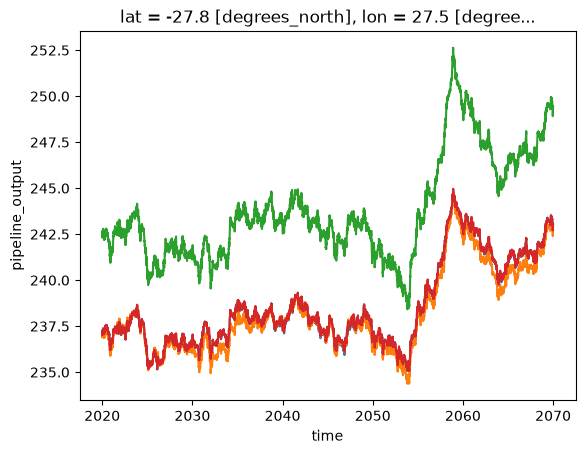

In [57]:
ds_debiased["nonparametric"].rolling(time=365 * 5).mean()[:, 0, 0].plot()
ds_debiased["parametric_low"].rolling(time=365 * 5).mean()[:, 0, 0].plot()
ds_debiased["parametric_high"].rolling(time=365 * 5).mean()[:, 0, 0].plot()
ds_debiased["pipeline_output"].rolling(time=365 * 5).mean()[:, 0, 0].plot()

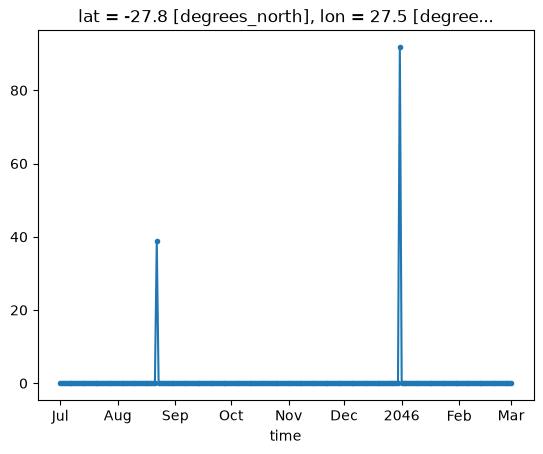

In [64]:
(ds_debiased["pipeline_output"] - ds_debiased["nonparametric"])[:, 0, 0].sel(
    time=slice("2045-07-01", "2046-03-01")
).plot(marker=".")

In [ ]:
"2045-08-22"
"2045-12-31"

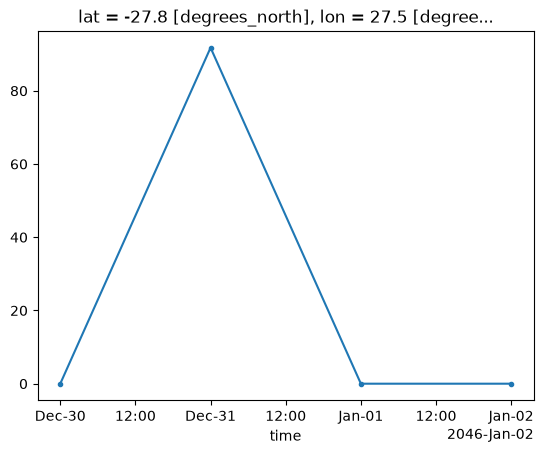

In [68]:
(ds_debiased["pipeline_output"] - ds_debiased["nonparametric"])[:, 0, 0].sel(
    time=slice("2045-12-30", "2046-01-02")
).plot(marker=".")

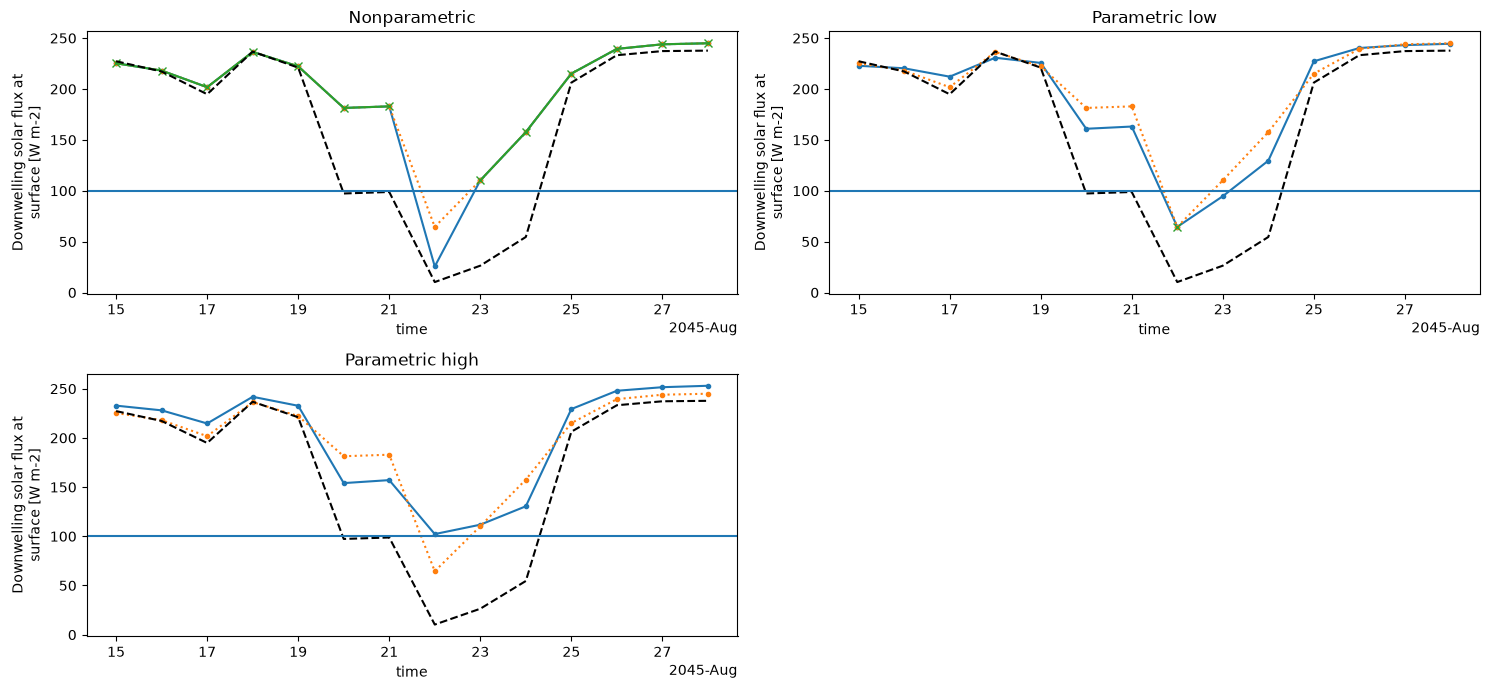

In [102]:
plt.figure(figsize=(15, 7))

time_slice = slice("2045-08-15", "2045-08-28")

plt.subplot(2, 2, 1)
(ds_debiased["nonparametric"])[:, 0, 0].sel(time=time_slice).plot(marker=".")
(ds_debiased["pipeline_output"])[:, 0, 0].sel(time=time_slice).plot(marker=".", linestyle=":")
(ds_debiased["pipeline_output"]).where(
    ds_debiased["pipeline_output"] == ds_debiased["nonparametric"]
)[:, 0, 0].sel(time=time_slice).plot(marker="x")
gcm_fut_pt.sel(time=time_slice).plot(color="k", linestyle="--")
plt.title("Nonparametric")

plt.axhline(y=100)
plt.subplot(2, 2, 2)
(ds_debiased["parametric_low"])[:, 0, 0].sel(time=time_slice).plot(marker=".")
(ds_debiased["pipeline_output"])[:, 0, 0].sel(time=time_slice).plot(marker=".", linestyle=":")
(ds_debiased["pipeline_output"]).where(
    ds_debiased["pipeline_output"] == ds_debiased["parametric_low"]
)[:, 0, 0].sel(time=time_slice).plot(marker="x")
gcm_fut_pt.sel(time=time_slice).plot(color="k", linestyle="--")
plt.title("Parametric low")

plt.axhline(y=100)
plt.subplot(2, 2, 3)
(ds_debiased["parametric_high"])[:, 0, 0].sel(time=time_slice).plot(marker=".")
(ds_debiased["pipeline_output"])[:, 0, 0].sel(time=time_slice).plot(marker=".", linestyle=":")
(ds_debiased["pipeline_output"]).where(
    ds_debiased["pipeline_output"] == ds_debiased["parametric_high"]
)[:, 0, 0].sel(time=time_slice).plot(marker="x")
gcm_fut_pt.sel(time=time_slice).plot(color="k", linestyle="--")
plt.title("Parametric high")

plt.axhline(y=100)
plt.tight_layout()

In [93]:
np.nanmax(
    gcm_hist_pt.where(gcm_hist_pt["time.dayofyear"] >= (234 - 15)).where(
        gcm_hist_pt["time.dayofyear"] <= (234 + 15)
    )
)

np.float32(273.6865)

In [97]:
np.nanmax(gcm_fut_pt.where(gcm_fut_pt["time.dayofyear"] == 234))

np.float32(247.99826)

In [98]:
np.nanmin(gcm_fut_pt.where(gcm_fut_pt["time.dayofyear"] == 234))

np.float32(10.297361)

In [110]:
gcm_fut_pt.sel(time="2045-08-22").values

array([[10.297361]], dtype=float32)

In [105]:
print(ds_debiased["nonparametric"].sel(time="2045-08-22")[0, 0].values)
print(ds_debiased["parametric_low"].sel(time="2045-08-22")[0, 0].values)
print(ds_debiased["parametric_high"].sel(time="2045-08-22")[0, 0].values)
print(ds_debiased["pipeline_output"].sel(time="2045-08-22")[0, 0].values)

25.60242
64.50701
102.25714
64.50701


In [107]:
np.nanmin(
    obs_coarse_pt.where(obs_coarse_pt["time.dayofyear"] >= (234 - 15)).where(
        obs_coarse_pt["time.dayofyear"] <= (234 + 15)
    )
)

np.float32(27.932816)

In [112]:
27.932816 + (10.297361 - 12.627757)

25.60242

In [108]:
np.nanmin(
    gcm_hist_pt.where(gcm_hist_pt["time.dayofyear"] >= (234 - 15)).where(
        gcm_hist_pt["time.dayofyear"] <= (234 + 15)
    )
)

np.float32(12.627757)